# **Implementación de los casos de 3, 5 y 10 qubits**

In [66]:
%load_ext autoreload
%autoreload 2

import modules
from modules.Schnorr_QAOA import SchnorrAlgQAOA


import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
seed = 99

## **Caso de 3 cubits**

In [7]:
N3 = 1961

In [8]:
threeQubit = SchnorrAlgQAOA(N3, 1.5, 1, seed)

El numero de bits de N = 1961 es m = 11
La dimension del reticulo que vamos a tratar es n = 3
La cota smooth que vamos a tomar: 9


In [9]:
B3, t3 = threeQubit.generate_cvp(10)
print(f'B3 = \n{B3}')
print(f't3 = \n{t3}')

B3 = 
[ 1 0 0 22 ]
[ 0 2 0 35 ]
[ 0 0 1 51 ]
t3 = 
(0, 0, 0, 240)


In [10]:
D3 = threeQubit.lll_reduced(B3, delta = 0.75)
print(f'D3 = \n{D3}')

D3 = 
[  3 2 -2 -1 ]
[ -4 2  1 -2 ]
[ -3 4  0  4 ]


In [11]:
D3, b3_op, res3_vector, sign_step3, w3, dist3 = threeQubit.babai_algorithm(B3, t3, delta = 0.75)
print(f'D3 = \n{D3}\n')
print(f'b3_op = \n{b3_op}\n')
print(f'res3_vector = \n{res3_vector}\n')
print(f'sign_step3 = \n{sign_step3}\n')
print(f'w3 = \n{w3}\n')
print(f'dist3 = \n{dist3}\n')

D3 = 
[  3 2 -2 -1 ]
[ -4 2  1 -2 ]
[ -3 4  0  4 ]

b3_op = 
[  0   2   4 239]

res3_vector = 
[ 0 -2 -4  1]

sign_step3 = 
[ 1 -1  1]

w3 = 
(-23, -42, 33)

dist3 = 
4.58257569495584



In [12]:
qubo3 = threeQubit.define_qubo(D3, res3_vector, sign_step3)

print(qubo3.prettyprint())

Problem name: quboProblem

Minimize
  18*z_0^2 + 16*z_0*z_1 - 10*z_0*z_2 + 25*z_1^2 - 24*z_1*z_2 + 41*z_2^2 - 6*z_0
  - 20*z_1 + 8*z_2 + 21

Subject to
  No constraints

  Binary variables (3)
    z_0 z_1 z_2



In [13]:
Hc3, offset3 = threeQubit.define_hamiltonian(qubo3)

print("Offset = {}\n".format(offset3))
print("Hamiltonian = {}".format(Hc3))

Offset = 49.5

Hamiltonian = SparsePauliOp(['IIZ', 'IZI', 'ZII', 'IZZ', 'ZIZ', 'ZZI'],
              coeffs=[ -7.5+0.j,  -0.5+0.j, -16. +0.j,   4. +0.j,  -2.5+0.j,  -6. +0.j])


In [14]:
circuit3 = threeQubit.construct_circuit(Hc3, 1)
print(circuit3.decompose(reps = 1))

     ┌───┐┌─────────────────────────────────────────────────────┐»
q_0: ┤ H ├┤0                                                    ├»
     ├───┤│                                                     │»
q_1: ┤ H ├┤1 exp(-it (IIZ + IZI + ZII + IZZ + ZIZ + ZZI))(γ[0]) ├»
     ├───┤│                                                     │»
q_2: ┤ H ├┤2                                                    ├»
     └───┘└─────────────────────────────────────────────────────┘»
«     ┌───────────────────────────────────┐
«q_0: ┤0                                  ├
«     │                                   │
«q_1: ┤1 exp(-it (XII + IXI + IIX))(β[0]) ├
«     │                                   │
«q_2: ┤2                                  ├
«     └───────────────────────────────────┘


In [15]:
x0 = np.asarray([0.0]*circuit3.num_parameters)

optParameters3 = threeQubit.qaoa_algorithm(circuit3, Hc3, x0)

/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


In [16]:
print(optParameters3)

{ParameterVectorElement(β[0]): np.float64(-0.651417868648273), ParameterVectorElement(γ[0]): np.float64(0.04646030232474015)}


In [17]:
ncircuit3 = threeQubit.circ_asign_params(circuit3, optParameters3)
print(ncircuit3.decompose(reps=2))

     ┌────────────┐┌─────────────┐                             ┌─────────────┐»
q_0: ┤ U(π/2,0,π) ├┤ Rz(-0.6969) ├──■─────────────■────────────┤ Rx(-1.3028) ├»
     ├────────────┤├─────────────┴┐ │ZZ(0.37168)  │            └─────────────┘»
q_1: ┤ U(π/2,0,π) ├┤ Rz(-0.04646) ├─■─────────────┼─────────────■─────────────»
     ├────────────┤├─────────────┬┘               │ZZ(-0.2323)  │ZZ(-0.55752) »
q_2: ┤ U(π/2,0,π) ├┤ Rz(-1.4867) ├────────────────■─────────────■─────────────»
     └────────────┘└─────────────┘                                            »
«                    
«q_0: ───────────────
«     ┌─────────────┐
«q_1: ┤ Rx(-1.3028) ├
«     ├─────────────┤
«q_2: ┤ Rx(-1.3028) ├
«     └─────────────┘


In [18]:
results3 = threeQubit.sample_from_parameters(circuit3, optParameters3, shots = 10_000)
print(len(results3))
for bitstring, count in results3.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

8
Bistring: 000 -> Counts: 3670
Bistring: 010 -> Counts: 3434
Bistring: 001 -> Counts: 1243
Bistring: 011 -> Counts: 594
Bistring: 110 -> Counts: 536
Bistring: 111 -> Counts: 346
Bistring: 100 -> Counts: 154
Bistring: 101 -> Counts: 23


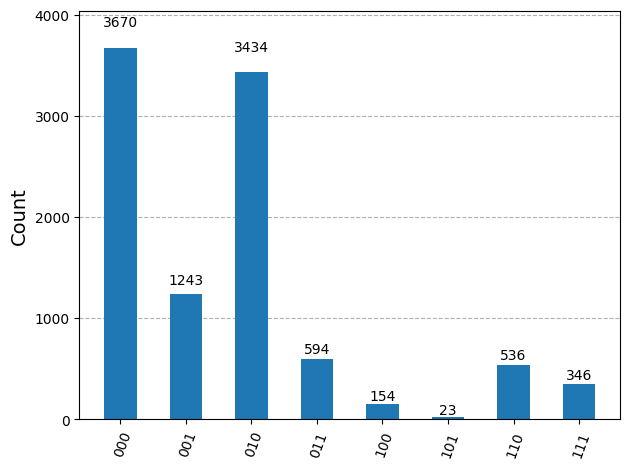

In [19]:
plot_histogram(results3)

In [20]:
nD3 = threeQubit.integer_to_matrix(D3)
print(nD3)

[[ 3  2 -2 -1]
 [-4  2  1 -2]
 [-3  4  0  4]]


In [21]:
vnew3 = threeQubit.bitstring2latticeVectors(nD3, results3.keys(), sign_step3, b3_op)
print(vnew3)

[[  0   2   4 239]
 [  4   0   3 241]
 [ -3   6   4 243]
 [  1   4   3 245]
 [  7   2   1 240]
 [  4   6   1 244]
 [  3   4   2 238]
 [  0   8   2 242]]


In [22]:
distances3 = threeQubit.get_distances(vnew3, t3)
for dist3 in distances3:
    print(np.linalg.norm(dist3))

4.58257569495584
5.0990195135927845
8.366600265340756
7.14142842854285
7.3484692283495345
8.306623862918075
5.744562646538029
8.48528137423857


In [23]:
nB3 = threeQubit.integer_to_matrix(B3)
print(nB3)

[[ 1  0  0 22]
 [ 0  2  0 35]
 [ 0  0  1 51]]


In [25]:
uv_pairs3 = threeQubit.vectors2uv_pairs(nB3, vnew3)
print(uv_pairs3)

[[1875 1]
 [2000 1]
 [16875 8]
 [2250 1]
 [1920 1]
 [2160 1]
 [1800 1]
 [2025 1]]


In [26]:
sr_pairs3 = threeQubit.uv_pairs2sr_pairs(uv_pairs3)
print(sr_pairs3)

[(2000, 1), (2250, 1), (1800, 1), (2025, 1)]


In [72]:
probs3 = threeQubit.get_probs(results3, shots = 10_000)

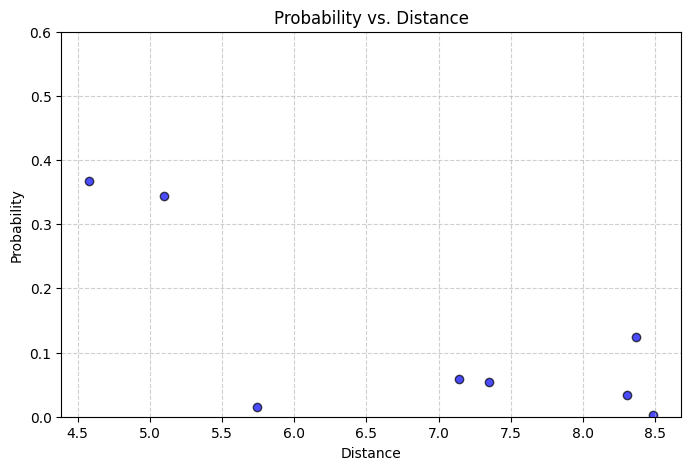

In [77]:
plt.figure(figsize=(8, 5))

# Creating the scatter plot
plt.scatter(distances3, probs3, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.60) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## **Caso de 5 cubits**

//Por hacer

In [27]:
N5 = 48567227

## **Caso de 10 cubits**

In [28]:
N10 = 261980999226229

### ***Implementación con 8 Qubits***

In [134]:
seed = 50

In [135]:
eightQubit = SchnorrAlgQAOA(N10, 4, 1, seed)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 64


In [136]:
B8, t8 = eightQubit.generate_cvp(10)
print(f'B8 = \n{B8}')
print(f't8 = \n{t8}')

B8 = 
[ 3 0 0 0 0 0 0 0  6931 ]
[ 0 3 0 0 0 0 0 0 10986 ]
[ 0 0 4 0 0 0 0 0 16094 ]
[ 0 0 0 2 0 0 0 0 19459 ]
[ 0 0 0 0 1 0 0 0 23979 ]
[ 0 0 0 0 0 2 0 0 25649 ]
[ 0 0 0 0 0 0 4 0 28332 ]
[ 0 0 0 0 0 0 0 1 29444 ]
t8 = 
(0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [137]:
D8, b8_op, res8_vector, sign_step8, w8, dist8 = eightQubit.babai_algorithm(B8, t8, delta = 0.75)
print(f'D8 = \n{D8}\n')
print(f'b8_op = \n{b8_op}\n')
print(f'res8_vector = \n{res8_vector}\n')
print(f'sign_step8 = \n{sign_step8}\n')
print(f'w8 = \n{w8}\n')
print(f'dist8 = \n{dist8}\n')

D8 = 
[  3 -3  4  0  2  0  4 -3 -3 ]
[  3 -3  4  0 -2 -4  4  2  3 ]
[  3  3  4 -4  0 -2 -4  2  0 ]
[ -3 -3  0 -6  2  0  4  0 -4 ]
[  6 -3  4  0 -4  6  0  0  1 ]
[  6  0 -4  0 -2  4  4 -1 -4 ]
[  0 -3  0 -2  5  0  4 -4  6 ]
[  6 -3 -4 -2  5  0 -4 -2 -2 ]

b8_op = 
[     3      0      0     -2      7      0      0      6 331989]

res8_vector = 
[-3  0  0  2 -7  0  0 -6  4]

sign_step8 = 
[-1  1 -1 -1  1 -1  1 -1]

w8 = 
(-25628, 8377, 3586, -10148, 7712, -1398, 27828, -4555)

dist8 = 
10.677078252031311



In [138]:
qubo8 = eightQubit.define_qubo(D8, res8_vector, sign_step8)
print(qubo8.prettyprint())

Hc8, offset8 = eightQubit.define_hamiltonian(qubo8)
print(f'Offset = {offset8}')
print(f'Hamiltonian = {Hc8}')


Problem name: quboProblem

Minimize
  72*z_0^2 - 62*z_0*z_1 - 12*z_0*z_2 + 64*z_0*z_3 - 64*z_0*z_4 + 58*z_0*z_5
  - 58*z_0*z_6 + 34*z_0*z_7 + 83*z_1^2 - 24*z_1*z_2 + 60*z_1*z_4 + 16*z_1*z_5
  + 50*z_1*z_6 + 50*z_1*z_7 + 74*z_2^2 - 20*z_2*z_3 - 26*z_2*z_4 - 48*z_2*z_5
  + 50*z_2*z_6 + 26*z_2*z_7 + 90*z_3^2 + 42*z_3*z_4 + 20*z_3*z_5 - 46*z_3*z_6
  + 10*z_3*z_7 + 114*z_4^2 - 96*z_4*z_5 - 10*z_4*z_6 - 14*z_4*z_7 + 105*z_5^2
  + 28*z_5*z_6 + 72*z_5*z_7 + 106*z_6^2 - 36*z_6*z_7 + 114*z_7^2 - 34*z_0
  - 10*z_1 - 58*z_2 - 66*z_3 - 28*z_4 - 28*z_5 - 18*z_6 - 106*z_7 + 114

Subject to
  No constraints

  Binary variables (8)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7

Offset = 335.0
Hamiltonian = SparsePauliOp(['IIIIIIIZ', 'IIIIIIZI', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'ZIIIIIII', 'IZIIIIII', 'IIIIIIZZ', 'IIIIIZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'IIZIIIIZ', 'IZIIIIIZ', 'ZIIIIIIZ', 'IIIIIZZI', 'IIIZIIZI', 'IIZIIIZI', 'IZIIIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIIZIZII', 'IIZIIZII', 'IZIIIZII', 'ZIIIIZI

In [139]:
circuit8 = eightQubit.construct_circuit(Hc8, reps = 1)
print(circuit8.decompose())

     ┌───┐»
q_0: ┤ H ├»
     ├───┤»
q_1: ┤ H ├»
     ├───┤»
q_2: ┤ H ├»
     ├───┤»
q_3: ┤ H ├»
     ├───┤»
q_4: ┤ H ├»
     ├───┤»
q_5: ┤ H ├»
     ├───┤»
q_6: ┤ H ├»
     ├───┤»
q_7: ┤ H ├»
     └───┘»
«     ┌──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐»
«q_0: ┤0                                                                                                                                                                                                                                                                                                                                                                                        

In [140]:
x0 = np.asarray([0.0]*circuit8.num_parameters)
optParameters8 = eightQubit.qaoa_algorithm(circuit8, Hc8, x0)

/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/home/zheng/tfg/TFG_GII/.venv/lib/python3.12/site-packages/scipy/sparse/_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [141]:
for param in optParameters8.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = -0.5405818657731905
γ[0] = 0.0114294620016492


In [142]:
results8 = eightQubit.sample_from_parameters(circuit8, optParameters8, shots = 10_000)
print(len(results8))
for bitstring, count in results8.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

223
Bistring: 00000000 -> Counts: 586
Bistring: 00000100 -> Counts: 530
Bistring: 00110100 -> Counts: 495
Bistring: 00001100 -> Counts: 449
Bistring: 00010101 -> Counts: 446
Bistring: 00000111 -> Counts: 345
Bistring: 00000101 -> Counts: 306
Bistring: 00000001 -> Counts: 299
Bistring: 00001000 -> Counts: 279
Bistring: 00110101 -> Counts: 267
Bistring: 00010100 -> Counts: 263
Bistring: 10000000 -> Counts: 254
Bistring: 00010001 -> Counts: 229
Bistring: 01010001 -> Counts: 201
Bistring: 00000011 -> Counts: 179
Bistring: 00100100 -> Counts: 176
Bistring: 00110000 -> Counts: 167
Bistring: 01000001 -> Counts: 155
Bistring: 01001000 -> Counts: 151
Bistring: 00000110 -> Counts: 134
Bistring: 10000100 -> Counts: 133
Bistring: 00010000 -> Counts: 126
Bistring: 01010101 -> Counts: 125
Bistring: 11001000 -> Counts: 113
Bistring: 00101100 -> Counts: 111
Bistring: 00111100 -> Counts: 110
Bistring: 11010001 -> Counts: 105
Bistring: 11000001 -> Counts: 101
Bistring: 10001000 -> Counts: 95
Bistring: 1

In [143]:
nD8 = eightQubit.integer_to_matrix(D8)
vnew8 = eightQubit.bitstring2latticeVectors(nD8, results8.keys(), sign_step8, b8_op)
for vect8 in vnew8:
    print(vect8)

[     3      0      0     -2      7      0      0      6 331989]
[    -3      0      4     -2      9     -4     -4      7 331993]
[    -3      0      0      8      7     -2     -4      5 331997]
[     3     -3      8     -2      5      2     -4      7 331994]
[    -6      6      8      6      2     -4     -4      9 331999]
[    -9      0      8     -2      9     -4      4      5 332001]
[    -9      3      8      0      4     -4      0      9 331995]
[    -3      3      4      0      2      0      4      8 331991]
[     9     -3      4     -2      3      6      0      6 331990]
[    -9      3      4     10      2     -2      0      7 331999]
[     0      3      4      4      7     -4     -8      7 331997]
[     0      3     -4     -2      5      0     -4      9 331992]
[     0      6      4      6      0      0      0      8 331995]
[     3      3      8      6     -2     -4      4     10 331998]
[    -3      0      4     -2      7      0      8      4 331997]
[    -6     -3      0    

In [144]:
distances8 = eightQubit.get_distances(vnew8, t8)
for dist8 in distances8:
    print(dist8)

10.677078252031311
13.820274961085254
13.527749258468683
13.45362404707371
18.027756377319946
18.734993995195193
16.46207763315433
11.045361017187261
14.142135623730951
17.291616465790582
15.329709716755891
12.328828005937952
12.489995996796797
16.703293088490067
13.19090595827292
12.609520212918492
11.575836902790225
15.652475842498529
18.24828759089466
17.52141546793523
16.941074346097416
11.74734012447073
21.540659228538015
15.652475842498529
11.090536506409418
13.74772708486752
18.788294228055936
15.968719422671311
13.19090595827292
13.92838827718412
12.767145334803704
16.941074346097416
17.08800749063506
19.87460691435179
18.947295321496416
14.594519519326424
19.4164878389476
13.674794331177344
17.804493814764857
15.716233645501712
22.781571499789035
18.16590212458495
13.92838827718412
15.491933384829668
13.341664064126334
19.570385790780925
11.40175425099138
14.212670403551895
21.118712081942874
16.278820596099706
16.34013463836819
24.413111231467404
20.346989949375804
15.8429795

In [145]:
nB8 = eightQubit.integer_to_matrix(B8)
uv_pairs8 = eightQubit.vectors2uv_pairs(nB8, vnew8)
print(uv_pairs8)

[[1833582255785302 7]
 [10538514015126023245 40222]
 [115853447266855529 442]
 [93573309334497850 357]
 [3013314192207413325 11492]
 [2481367565888398825 9464]
 [354335293738675425 1352]
 [524027837630055 2]
 [5502875781654680 21]
 [27267293706031995 104]
 [12802988101020871215 48841]
 [155907529245017187 595]
 [262141295537835 1]
 [5362537102385644650 20449]
 [3669704099182495 14]
 [40869583438161863 156]
 [1310217324462046 5]
 [44296953712612225 169]
 [16514816701068400 63]
 [13023520542737250095 49686]
 [358431409734294512913 1367548]
 [4455150274387428 17]
 [14983559550783418875 57122]
 [60574934627073880 231]
 [2358773171589835 9]
 [13372879303393610 51]
 [649087799739937705665 2474329]
 [10723510782875550045 40898]
 [31193574368900372 119]
 [1048412330083971 4]
 [310097069187058978 1183]
 [115638116969868350 441]
 [1078816287656406159 4114]
 [435449729181333003291 1660594]
 [177326705000289075 676]
 [530429197293653515 2023]
 [11517207965279178500 43923]
 [929974735847470940 3549

In [146]:
sr_pairs8 = eightQubit.uv_pairs2sr_pairs(uv_pairs8)
print(sr_pairs8)

[]


No obtenemos nada

In [147]:
probs8 = eightQubit.get_probs(results8, shots = 10_000)

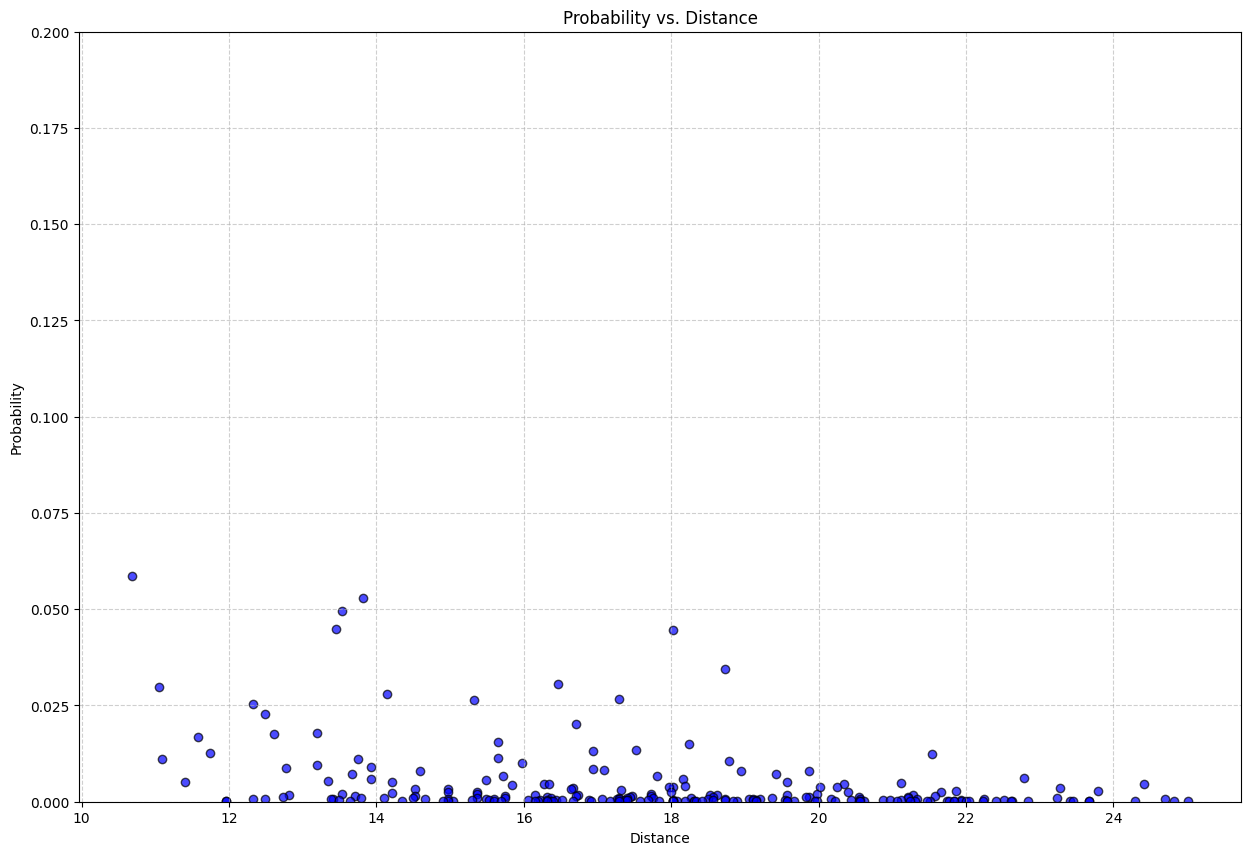

In [148]:
plt.figure(figsize=(15, 10))

# Creating the scatter plot
plt.scatter(distances8, probs8, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.20) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### ***Implementación con 10 Qubits***

Usar parámetros establecidos en los experimentos del equipo de Yan et al.

In [149]:
seed = 91

In [150]:
tenQubit = SchnorrAlgQAOA(N10, 4, 1, 42)

El numero de bits de N = 261980999226229 es m = 48
La dimension del reticulo que vamos a tratar es n = 8
La cota smooth que vamos a tomar: 64


In [151]:
tenQubit.set_n(10)
tenQubit.set_smoothbound(200)

print(f'La dimension del retículo que vamos a tratar es n = {tenQubit.get_n()}')
print(f'La cota smooth que vamos a tomar es Smooth Bound = {tenQubit.get_smoothbound()}')

La dimension del retículo que vamos a tratar es n = 10
La cota smooth que vamos a tomar es Smooth Bound = 200


In [152]:
B10, t10 = tenQubit.generate_cvp(10)
print(f'B10 = \n{B10}')
print(f't10 = \n{t10}')

B10 = 
[ 5 0 0 0 0 0 0 0 0 0  6931 ]
[ 0 1 0 0 0 0 0 0 0 0 10986 ]
[ 0 0 3 0 0 0 0 0 0 0 16094 ]
[ 0 0 0 1 0 0 0 0 0 0 19459 ]
[ 0 0 0 0 4 0 0 0 0 0 23979 ]
[ 0 0 0 0 0 2 0 0 0 0 25649 ]
[ 0 0 0 0 0 0 5 0 0 0 28332 ]
[ 0 0 0 0 0 0 0 3 0 0 29444 ]
[ 0 0 0 0 0 0 0 0 2 0 31355 ]
[ 0 0 0 0 0 0 0 0 0 4 33673 ]
t10 = 
(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 331993)


In [153]:
D10, b10_op, res10_vector, sign_step10, w10, dist10 = tenQubit.babai_algorithm(B10, t10, delta = 0.75)
print(f'D10 = \n{D10}\n')
print(f'b10_op = \n{b10_op}\n')
print(f'res10_vector = \n{res10_vector}\n')
print(f'sign_step10 = \n{sign_step10}\n')
print(f'w10 = \n{w10}\n')
print(f'dist10 = \n{dist10}\n')

D10 = 
[  0  1  3 -1  0  2  0  3 -4  0  4 ]
[  5  3 -3  2  0  0  0  0 -4  0  3 ]
[  0  4 -3  1 -4 -2  0  0 -2  4 -1 ]
[  0  4 -3 -1  0  4 -5  0 -2  0  2 ]
[  0  1 -3 -3  0 -2  5  3  2  0 -3 ]
[  0 -1 -6  0  0 -4  0  3  2  4  0 ]
[ -5 -2  3  4  0  0  0  0 -2 -4 -1 ]
[  0  5  0  3  0 -4 -5  0  0 -4  4 ]
[ -5  4  0 -2  0  0  0 -3  2  0  6 ]
[ -5  2  0  1  4  0  0 -3 -4  4 -2 ]

b10_op = 
[     0      1      0      6      0      4      0      6      6      0
 331991]

res10_vector = 
[ 0 -1  0 -6  0 -4  0 -6 -6  0  2]

sign_step10 = 
[ 1  1  1 -1 -1 -1 -1  1  1  1]

w10 = 
(15714, 20489, -11636, -10577, -17862, 19313, 3326, -7285, 28799, -11636)

dist10 = 
11.357816691600547



In [154]:
qubo10 = tenQubit.define_qubo(D10, res10_vector, sign_step10)
print(qubo10.prettyprint())
Hc10, offset10 = tenQubit.define_hamiltonian(qubo10)
print(f'Offset = {offset10}')
print(f'Hamiltonian = \n{Hc10}')

Problem name: quboProblem

Minimize
  56*z_0^2 + 40*z_0*z_1 - 12*z_0*z_2 - 40*z_0*z_3 + 40*z_0*z_4 + 52*z_0*z_5
  - 14*z_0*z_6 + 20*z_0*z_7 + 26*z_0*z_8 + 72*z_1^2 + 56*z_1*z_2 - 66*z_1*z_3
  + 22*z_1*z_4 - 14*z_1*z_5 + 54*z_1*z_6 + 66*z_1*z_7 - 14*z_1*z_8 - 14*z_1*z_9
  + 67*z_2^2 - 36*z_2*z_3 - 26*z_2*z_4 - 68*z_2*z_5 + 48*z_2*z_6 + 22*z_2*z_7
  + 8*z_2*z_8 + 38*z_2*z_9 + 75*z_3^2 - 54*z_3*z_4 - 12*z_3*z_5 - 38*z_3*z_6
  - 68*z_3*z_7 - 52*z_3*z_8 - 22*z_3*z_9 + 70*z_4^2 + 76*z_4*z_5 - 48*z_4*z_6
  + 66*z_4*z_7 + 26*z_4*z_8 + 24*z_4*z_9 + 82*z_5^2 - 72*z_5*z_6 + 10*z_5*z_7
  + 18*z_5*z_8 + 6*z_5*z_9 + 75*z_6^2 - 28*z_6*z_7 + 2*z_6*z_8 - 38*z_6*z_9
  + 107*z_7^2 + 76*z_7*z_8 - 22*z_7*z_9 + 94*z_8^2 + 40*z_8*z_9 + 91*z_9^2
  - 22*z_0 - 30*z_1 - 16*z_2 + 4*z_3 - 22*z_4 - 26*z_5 - 24*z_6 - 2*z_7 - 52*z_8
  - 60*z_9 + 129

Subject to
  No constraints

  Binary variables (10)
    z_0 z_1 z_2 z_3 z_4 z_5 z_6 z_7 z_8 z_9

Offset = 418.0
Hamiltonian = 
SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI'

In [155]:
circuit10 = tenQubit.construct_circuit(Hc10, reps= 1)
print(circuit10.decompose(reps = 2))

     ┌────────────┐ ┌────────────────┐                              »
q_0: ┤ U(π/2,0,π) ├─┤ Rz((-90)*γ[0]) ├─■─────────────■──────────────»
     ├────────────┤┌┴────────────────┤ │ZZ(20*γ[0])  │              »
q_1: ┤ U(π/2,0,π) ├┤ Rz((-107)*γ[0]) ├─■─────────────┼──────────────»
     ├────────────┤└┬────────────────┤               │ZZ((-6)*γ[0]) »
q_2: ┤ U(π/2,0,π) ├─┤ Rz((-66)*γ[0]) ├───────────────■──────────────»
     ├────────────┤ └┬──────────────┬┘                              »
q_3: ┤ U(π/2,0,π) ├──┤ Rz(115*γ[0]) ├───────────────────────────────»
     ├────────────┤┌─┴──────────────┴┐                              »
q_4: ┤ U(π/2,0,π) ├┤ Rz((-111)*γ[0]) ├──────────────────────────────»
     ├────────────┤└┬────────────────┤                              »
q_5: ┤ U(π/2,0,π) ├─┤ Rz((-54)*γ[0]) ├──────────────────────────────»
     ├────────────┤ └┬─────────────┬─┘                              »
q_6: ┤ U(π/2,0,π) ├──┤ Rz(16*γ[0]) ├────────────────────────────────»
     ├────────────┤┌

In [156]:
x0 = np.asarray([0.0]*circuit10.num_parameters)
optParameters10 = tenQubit.qaoa_algorithm(circuit10, Hc10, x0)

In [157]:
for param in optParameters10.items():
    print(f'{param[0].name} = {param[1]}')

β[0] = -0.5089978305652973
γ[0] = 0.008621521415162203


In [158]:
results10 = tenQubit.sample_from_parameters(circuit10, optParameters10, shots = 10_000)
print(len(results10))
for bitstring, count in results10.items():
    print(f"Bistring: {bitstring} -> Counts: {count}")

586
Bistring: 1001001000 -> Counts: 253
Bistring: 0000000000 -> Counts: 225
Bistring: 0000001000 -> Counts: 220
Bistring: 0001001000 -> Counts: 201
Bistring: 1001101000 -> Counts: 195
Bistring: 0001011000 -> Counts: 179
Bistring: 0001101100 -> Counts: 171
Bistring: 0001101000 -> Counts: 167
Bistring: 1001001001 -> Counts: 161
Bistring: 1011001000 -> Counts: 147
Bistring: 1000001000 -> Counts: 139
Bistring: 0000001010 -> Counts: 135
Bistring: 0000001100 -> Counts: 133
Bistring: 1001011000 -> Counts: 132
Bistring: 0000001001 -> Counts: 127
Bistring: 0000101100 -> Counts: 119
Bistring: 1000001010 -> Counts: 115
Bistring: 0001001001 -> Counts: 114
Bistring: 0100001000 -> Counts: 109
Bistring: 1001101010 -> Counts: 106
Bistring: 0001000000 -> Counts: 104
Bistring: 1000000000 -> Counts: 101
Bistring: 1001101100 -> Counts: 101
Bistring: 0100001010 -> Counts: 100
Bistring: 0011001000 -> Counts: 95
Bistring: 1011101000 -> Counts: 94
Bistring: 0001100000 -> Counts: 91
Bistring: 0001111100 -> Cou

In [159]:
nD10 = tenQubit.integer_to_matrix(D10)
vnew10 = tenQubit.bitstring2latticeVectors(nD10, results10.keys(), sign_step10, b10_op)
for vect10 in vnew10:
    print(vect10)

[     5      0      3      2      0      2      5      9      6      4
 331994]
[     0      1      0      6      0      4      0      6      6      0
 331991]
[     5      3     -3      2      0      4      0      6      8      4
 331992]
[     5     -1      0      3      0      0      5      6     10      4
 331990]
[     5     -1      6      5      0      4      0      6      4      4
 331997]
[     5      0      6      3      0      4      5      3      8      0
 331990]
[     5      3      3      9      0     -2     -5      3      8      0
 331997]
[     5     -2      3      6      0      2      0      3      8      4
 331993]
[     0      2      3      3      4      2      5      6      2      8
 331992]
[     5      4      0      3     -4      0      5      9      4      8
 331993]
[     5      4      0      1      0      6      0      9      4      4
 331996]
[     0      7     -3      0      0      4      0      3     10      4
 331998]
[     5      8     -3      5      0     

In [160]:
distances10 = tenQubit.get_distances(vnew10, t10)
for dist10 in distances10:
    print(dist10)

14.177446878757825
11.357816691600547
13.416407864998739
14.866068747318506
13.674794331177344
13.892443989449804
15.556349186104045
12.922847983320086
13.114877048604
15.874507866387544
14.142135623730951
14.966629547095765
16.0312195418814
15.0
13.152946437965905
17.97220075561143
16.431676725154983
13.856406460551018
16.61324772583615
15.198684153570664
14.422205101855956
12.767145334803704
16.792855623746664
17.4928556845359
16.852299546352718
14.560219778561036
14.212670403551895
17.320508075688775
15.0996688705415
15.165750888103101
12.806248474865697
15.84297951775486
14.212670403551895
15.84297951775486
14.560219778561036
13.601470508735444
15.297058540778355
14.798648586948742
15.811388300841896
12.649110640673518
18.65475810617763
13.892443989449804
14.798648586948742
16.15549442140351
13.416407864998739
14.2828568570857
15.362291495737216
20.46948949045872
16.703293088490067
13.30413469565007
13.490737563232042
15.033296378372908
13.038404810405298
14.594519519326424
14.6628

In [161]:
nB10 = tenQubit.integer_to_matrix(B10)
uv_pairs10 = tenQubit.vectors2uv_pairs(nB10, vnew10)
for pair10 in uv_pairs10:
    print(pair10)

[262078058335730 1]
[261991323844341 1]
[1310065736807646 5]
[785809757098954 3]
[786516396634150 3]
[261977923439050 1]
[57931005868178310 221]
[2358275479138670 9]
[262012871275155 1]
[2882508035594922 11]
[262154661348762 1]
[1310769316687779 5]
[22279671311401854 85]
[262119418401750 1]
[1309739882231781 5]
[75778073514523926 289]
[1836068173280991 7]
[261871433827773 1]
[6552805178814804 25]
[262312933571325 1]
[7071698751104155 27]
[262132826044635 1]
[4458638042784450 17]
[6556324408234146 25]
[187261881680842038 715]
[2883542722375770 11]
[21222711489550025 81]
[129251100049139250 493]
[22274129656016469 85]
[44284284952292574 169]
[262054497183570 1]
[129242486897948970 493]
[2358506064707975 9]
[1310178082724532 5]
[7600277737807650 29]
[262171334146995 1]
[129211330479893361 493]
[262218809172645 1]
[4458215395202751 17]
[523852316714727 2]
[2197381093096279545 8381]
[262089455234607 1]
[262129675185924 1]
[261981005921397 1]
[4455822364931574 17]
[2881986154104582 11]
[7078

In [162]:
sr_pairs10 = tenQubit.uv_pairs2sr_pairs(uv_pairs10)
print(sr_pairs10)

[]


In [163]:
probs10 = tenQubit.get_probs(results10, shots = 10_000)

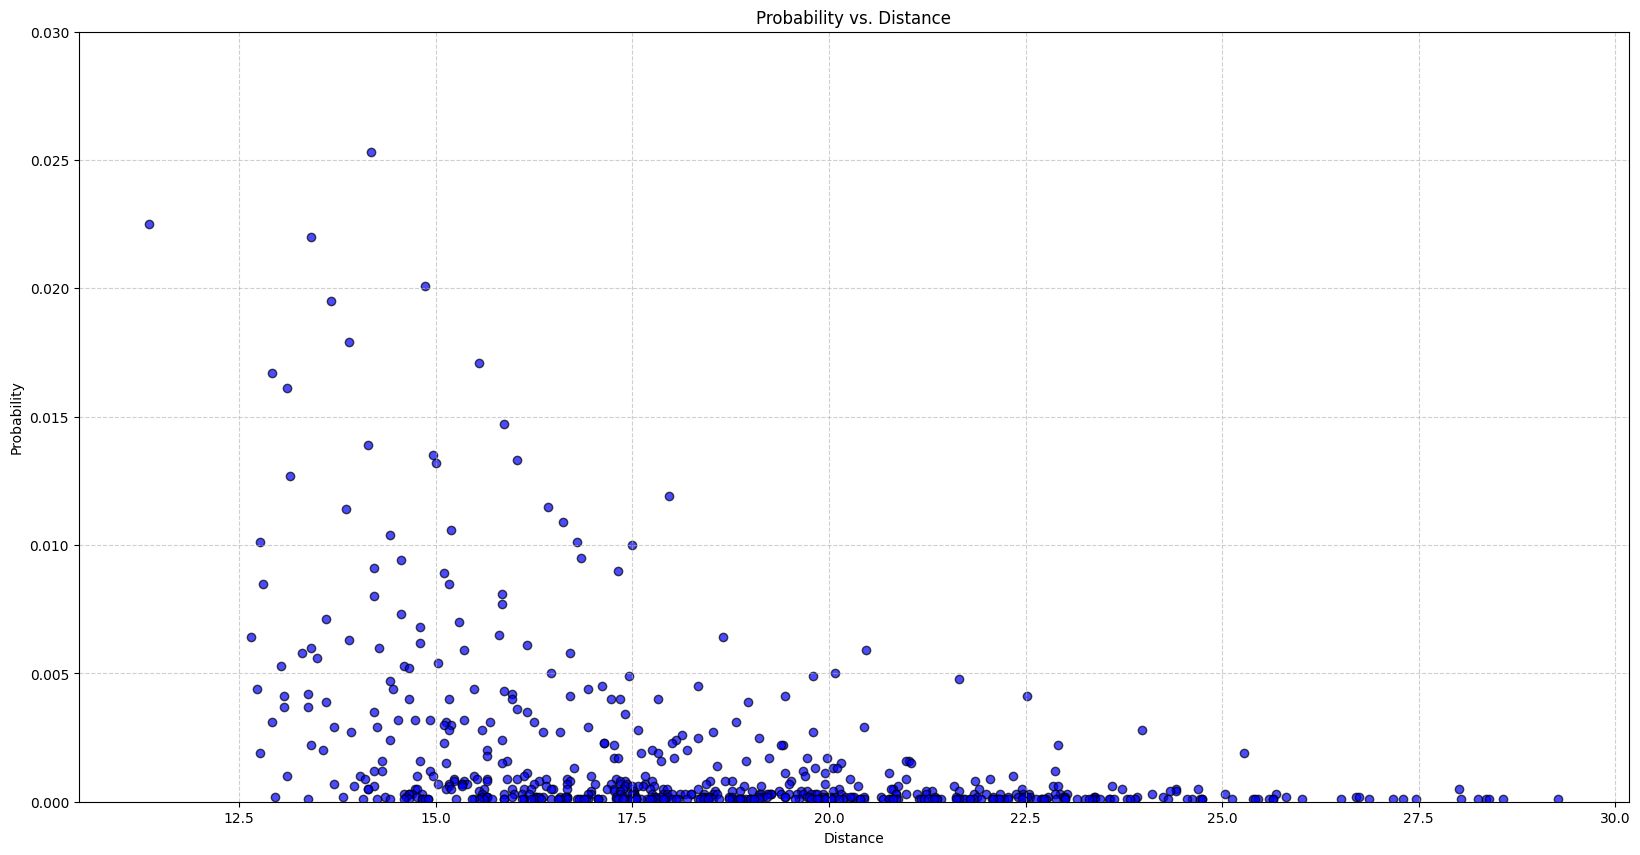

In [164]:
plt.figure(figsize=(20, 10))

# Creating the scatter plot
plt.scatter(distances10, probs10, color='blue', edgecolors='black', alpha=0.7)

# Adding labels and title
plt.xlabel('Distance')
plt.ylabel('Probability')
plt.title('Probability vs. Distance')

# Setting y-axis limit since you mentioned probs are <= 0.2
plt.ylim(0, 0.03) 

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()